# E003 — Audio: GMM-UBM + MAP Adaptation

**Hypothesis:** A UBM trained on all non-target frames encodes a compact
prior over the acoustic space. MAP-adapting its means toward the target
speaker requires far fewer parameters to move than training an independent
GMM, yielding better-regularised target models especially when target data
is scarce.

Same features as E002 — MFCC 13+Δ+ΔΔ, CMN per utterance — the only change
is the modelling back-end.

**MAP formula (means only, r = 16):**

$$
\alpha_k = \frac{n_k}{n_k + r}, \qquad
\mu_k' = \alpha_k\,\hat{\mu}_k + (1-\alpha_k)\,\mu_k^{\text{UBM}}
$$

where $n_k$ is the expected number of target frames assigned to component
$k$, and $r$ is the relevance factor (prior strength).

In [1]:
from pathlib import Path
import sys
import copy
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from scipy.special import logsumexp
from scipy.stats import norm as sp_norm

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
C_TARGET    = "#E74C3C"   # tomato
C_NONTARGET = "#2E86AB"   # steelblue
C_GREEN     = "#27AE60"   # green  (threshold)
C_PURPLE    = "#8E44AD"   # purple (EER marker)
C_GRAY      = "#95A5A6"   # gray   (E001)

DATA = Path("../data").resolve()
manifest = load_manifest(DATA)
print(f"{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target")

222 samples — 30 target, 192 non-target


## Feature extraction

Identical to E002: 13 MFCCs + first and second order deltas → 39-dimensional
feature vectors. CMN (cepstral mean normalisation) is applied per utterance
to suppress channel effects.

In [2]:
def extract_mfcc(wav_path: Path, n_mfcc: int = 13) -> np.ndarray:
    y, sr  = librosa.load(wav_path, sr=None, mono=True)
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc   = np.vstack([mfcc, delta, delta2]).T
    mfcc  -= mfcc.mean(axis=0)   # CMN
    return mfcc


def find_wav(stem: str, data_dir: Path) -> Path:
    for sf in ["target_train", "target_dev", "non_target_train", "non_target_dev"]:
        p = data_dir / sf / (stem + ".wav")
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def extract_batch(df, data_dir: Path):
    all_mfcc, all_labels = [], []
    for _, row in df.iterrows():
        mfcc = extract_mfcc(find_wav(row["stem"], data_dir))
        all_mfcc.append(mfcc)
        all_labels.extend([row["label"]] * len(mfcc))
    return np.vstack(all_mfcc), np.array(all_labels)

## UBM training and MAP adaptation

The UBM is a 32-component diagonal GMM fit to non-target frames. MAP
adaptation moves only the component means; weights and covariances stay
fixed (standard practice — there are too few target frames to reliably
estimate covariances).

The LLR score for an utterance is the frame-averaged log-likelihood ratio
between the adapted model and the UBM.

In [3]:
def train_ubm(X: np.ndarray, n_components: int = 32, seed: int = 67) -> GaussianMixture:
    """Train UBM on non-target frames."""
    gmm = GaussianMixture(
        n_components=n_components, covariance_type="diag",
        max_iter=200, random_state=seed,
    )
    gmm.fit(X)
    return gmm


def map_adapt(ubm: GaussianMixture, X_target: np.ndarray, r: float = 16.0) -> GaussianMixture:
    """
    MAP-adapt UBM means toward target data.  Weights and covariances are frozen.

    1. E-step: posterior P(k | frame) via log-responsibilities
    2. Sufficient statistics: n_k, mu_hat_k
    3. alpha_k = n_k / (n_k + r)
    4. adapted_means = alpha * mu_hat + (1-alpha) * ubm.means_
    """
    log_prob    = ubm._estimate_log_prob(X_target)           # (T, K)
    log_weights = np.log(ubm.weights_)                       # (K,)
    log_resp    = log_prob + log_weights                     # (T, K)
    log_resp   -= logsumexp(log_resp, axis=1, keepdims=True) # normalise
    resp        = np.exp(log_resp)                           # (T, K) posteriors

    n_k    = resp.sum(axis=0)                                # (K,)
    mu_hat = (resp.T @ X_target) / (n_k[:, None] + 1e-10)   # (K, D)

    alpha         = n_k / (n_k + r)                         # (K,)
    adapted_means = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_

    adapted        = copy.deepcopy(ubm)
    adapted.means_ = adapted_means
    return adapted


def score_utterance(wav_path: Path, adapted: GaussianMixture, ubm: GaussianMixture) -> float:
    """Frame-averaged LLR: log P(x|adapted) − log P(x|UBM)."""
    mfcc = extract_mfcc(wav_path)
    llr  = adapted.score_samples(mfcc) - ubm.score_samples(mfcc)
    return float(llr.mean())

## Cross-validation — Leave-One-Session-Out

Three folds; fold $i$ holds out target session $i$ and a matching set of
non-target speakers.  We store the trained UBM and adapted model objects
from each fold so we can inspect them visually later.

In [4]:
UBM_COMPONENTS = 32
MAP_R          = 16.0
SEED           = 67

oof_scores   = np.full(len(manifest), np.nan)
fold_results = []
fold_models  = {}   # {fold_id: {"ubm": ..., "adapted": ...}}

for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]
    print(f"Fold {fold_id}: train={len(train_df)}, val={len(val_df)}")

    print("  Extracting features...")
    X_train, y_train = extract_batch(train_df, DATA)
    X_nt = X_train[y_train == 0]
    X_t  = X_train[y_train == 1]
    print(f"  Frames: {len(X_t)} target, {len(X_nt)} non-target")

    print("  Training UBM...")
    ubm = train_ubm(X_nt, n_components=UBM_COMPONENTS, seed=SEED)

    print("  MAP adapting to target...")
    adapted = map_adapt(ubm, X_t, r=MAP_R)

    fold_models[fold_id] = {"ubm": ubm, "adapted": adapted}

    print("  Scoring val fold...")
    for idx, row in val_df.iterrows():
        wav = find_wav(row["stem"], DATA)
        oof_scores[idx] = score_utterance(wav, adapted, ubm)

    val_scores  = oof_scores[val_idx]
    val_labels  = manifest.loc[val_idx, "label"].to_numpy()
    eer, _      = compute_eer(val_scores[val_labels == 1], val_scores[val_labels == 0])
    min_dcf, _  = compute_min_dcf(val_scores[val_labels == 1], val_scores[val_labels == 0])
    fold_results.append({"fold": fold_id, "eer": eer, "min_dcf": min_dcf})
    print(f"  → EER = {eer*100:.2f}%, min-DCF = {min_dcf:.4f}\n")

print("Done.")

Fold 0: train=140, val=82
  Extracting features...
  Frames: 5102 target, 56982 non-target
  Training UBM...
  MAP adapting to target...
  Scoring val fold...
  → EER = 9.86%, min-DCF = 0.1389

Fold 1: train=152, val=70
  Extracting features...
  Frames: 5540 target, 59888 non-target
  Training UBM...
  MAP adapting to target...
  Scoring val fold...
  → EER = 10.83%, min-DCF = 0.1333

Fold 2: train=152, val=70
  Extracting features...
  Frames: 5684 target, 62852 non-target
  Training UBM...
  MAP adapting to target...
  Scoring val fold...
  → EER = 1.67%, min-DCF = 0.0333

Done.


## Summary table

In [5]:
results_df = pd.DataFrame(fold_results)
mean_eer   = results_df["eer"].mean()
std_eer    = results_df["eer"].std()
mean_dcf   = results_df["min_dcf"].mean()
std_dcf    = results_df["min_dcf"].std()

y_all = manifest["label"].to_numpy()
eer_oof, _   = compute_eer(oof_scores[y_all == 1], oof_scores[y_all == 0])
dcf_oof, thr = compute_min_dcf(oof_scores[y_all == 1], oof_scores[y_all == 0])

print("=" * 50)
print(f"{'Fold':<8} {'EER [%]':>12} {'min-DCF':>12}")
print("-" * 50)
for _, r in results_df.iterrows():
    print(f"{int(r.fold):<8} {r.eer*100:>12.2f} {r.min_dcf:>12.4f}")
print("-" * 50)
print(f"{'mean±std':<8} {mean_eer*100:>9.2f}±{std_eer*100:.2f} {mean_dcf:>9.4f}±{std_dcf:.4f}")
print("=" * 50)
print(f"\nOOF overall : EER = {eer_oof*100:.2f}%, min-DCF = {dcf_oof:.4f}, threshold = {thr:.4f}")
print()
print(f"E001 (static MFCC)  : EER = 17.92 ± 7.81%")
print(f"E002 (MFCC+Δ+ΔΔ)   : EER = 10.09 ± 1.81%")
print(f"E003 (UBM+MAP)      : EER = {mean_eer*100:.2f} ± {std_eer*100:.2f}%")
print(f"Change vs E002      : {(mean_eer*100 - 10.09):+.2f}% EER")

Fold          EER [%]      min-DCF
--------------------------------------------------
0                9.86       0.1389
1               10.83       0.1333
2                1.67       0.0333
--------------------------------------------------
mean±std      7.45±5.04    0.1019±0.0594

OOF overall : EER = 12.14%, min-DCF = 0.1510, threshold = -0.0302

E001 (static MFCC)  : EER = 17.92 ± 7.81%
E002 (MFCC+Δ+ΔΔ)   : EER = 10.09 ± 1.81%
E003 (UBM+MAP)      : EER = 7.45 ± 5.04%
Change vs E002      : -2.64% EER


## Visualisation 1 — Score distributions

Each panel shows the LLR score histogram for one fold (plus the overall OOF
in the bottom-right).  The **green dashed line** marks the min-DCF threshold.
Good separation means the two histograms barely overlap; the overlap region
determines EER.  Comparing these panels across folds reveals whether session
3 (the harder val set) shows more overlap than sessions 1–2.

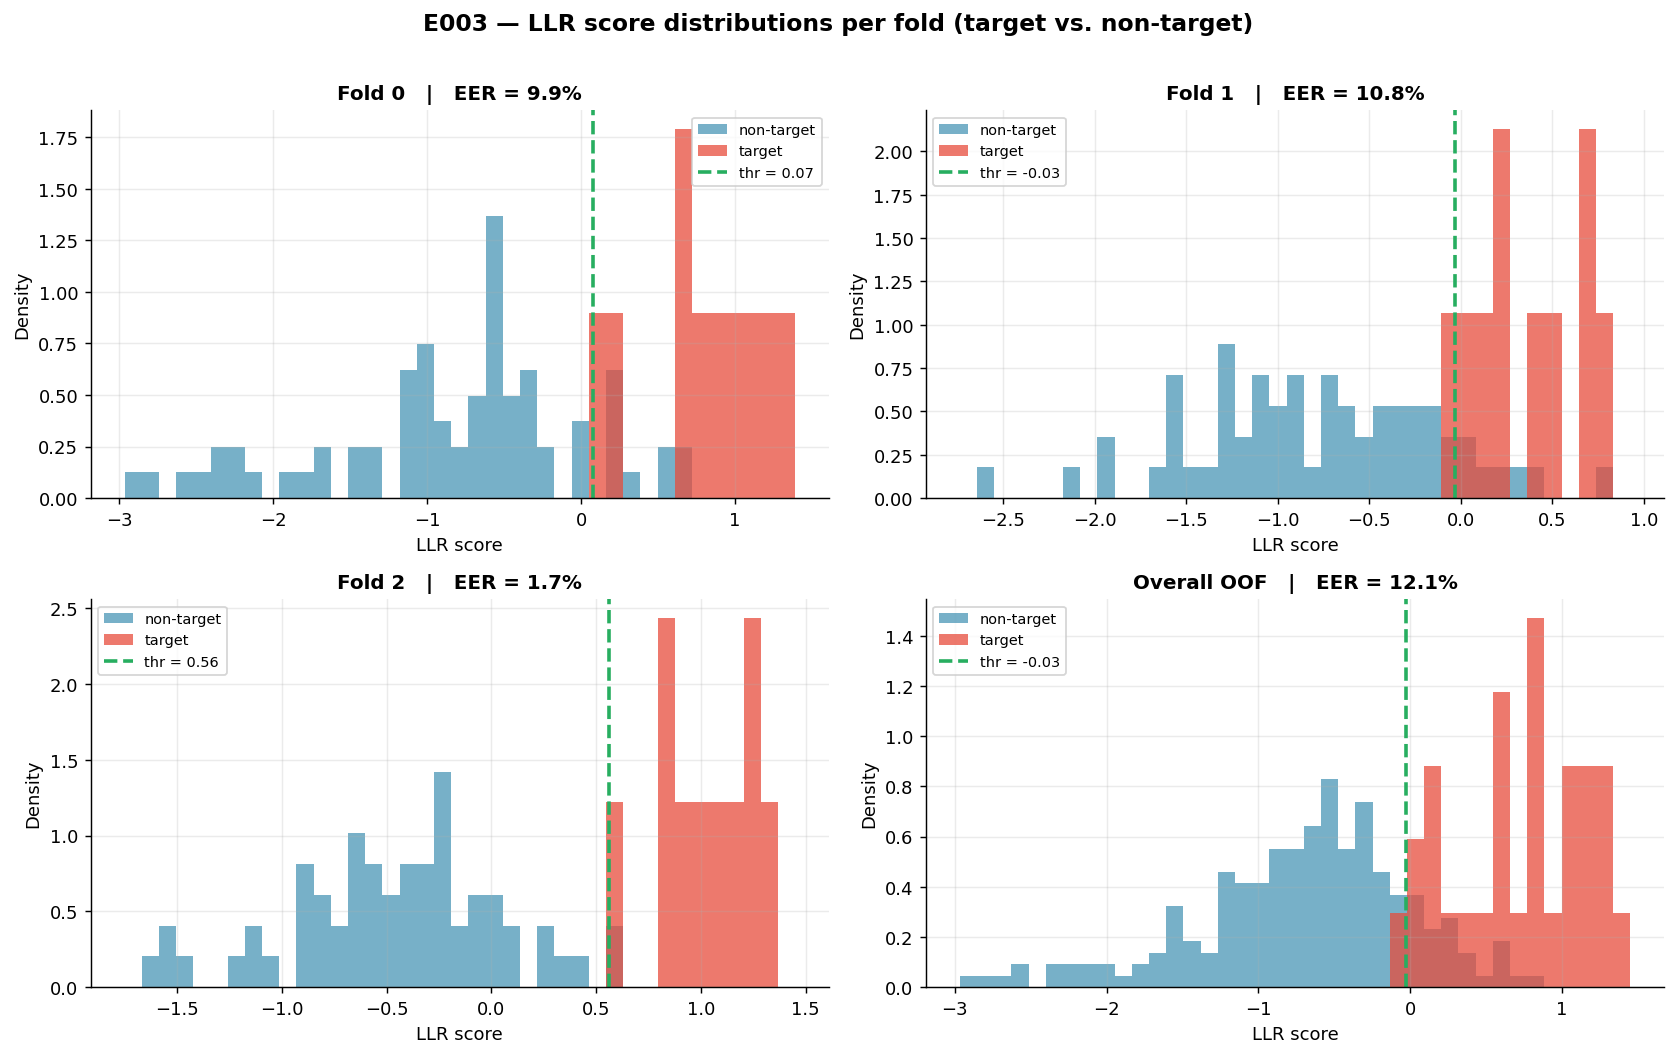

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes_flat = axes.flatten()

panels = [(0, "Fold 0"), (1, "Fold 1"), (2, "Fold 2"), (None, "Overall OOF")]

for ax, (fold_id, title) in zip(axes_flat, panels):
    if fold_id is not None:
        fold_info  = fold_results[fold_id]
        val_mask   = np.zeros(len(manifest), dtype=bool)
        for _, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
            if _ == fold_id:
                val_mask[val_idx] = True
                break
        s_tgt = oof_scores[val_mask & (y_all == 1)]
        s_nt  = oof_scores[val_mask & (y_all == 0)]
        _, thr_fold = compute_min_dcf(s_tgt, s_nt)
        eer_val = fold_info["eer"]
    else:
        s_tgt     = oof_scores[y_all == 1]
        s_nt      = oof_scores[y_all == 0]
        thr_fold  = thr
        eer_val   = eer_oof

    all_s = np.concatenate([s_tgt, s_nt])
    bins  = np.linspace(all_s.min() - 0.1, all_s.max() + 0.1, 40)

    ax.hist(s_nt,  bins=bins, alpha=0.65, color=C_NONTARGET, label="non-target", density=True)
    ax.hist(s_tgt, bins=bins, alpha=0.75, color=C_TARGET,    label="target",     density=True)
    ax.axvline(thr_fold, color=C_GREEN, ls="--", lw=2, label=f"thr = {thr_fold:.2f}")
    ax.set_title(f"{title}   |   EER = {eer_val*100:.1f}%", fontsize=11, fontweight="bold")
    ax.set_xlabel("LLR score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("E003 — LLR score distributions per fold (target vs. non-target)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Visualisation 2 — ROC curve

The ROC curve shows the trade-off between FAR (False Acceptance Rate) and
1−FRR (True Acceptance Rate) for all possible thresholds.  The **purple dot**
marks the EER operating point where FAR = FRR.  A curve hugging the top-left
corner (AUC → 1) is ideal.  The dashed diagonal is a random classifier.

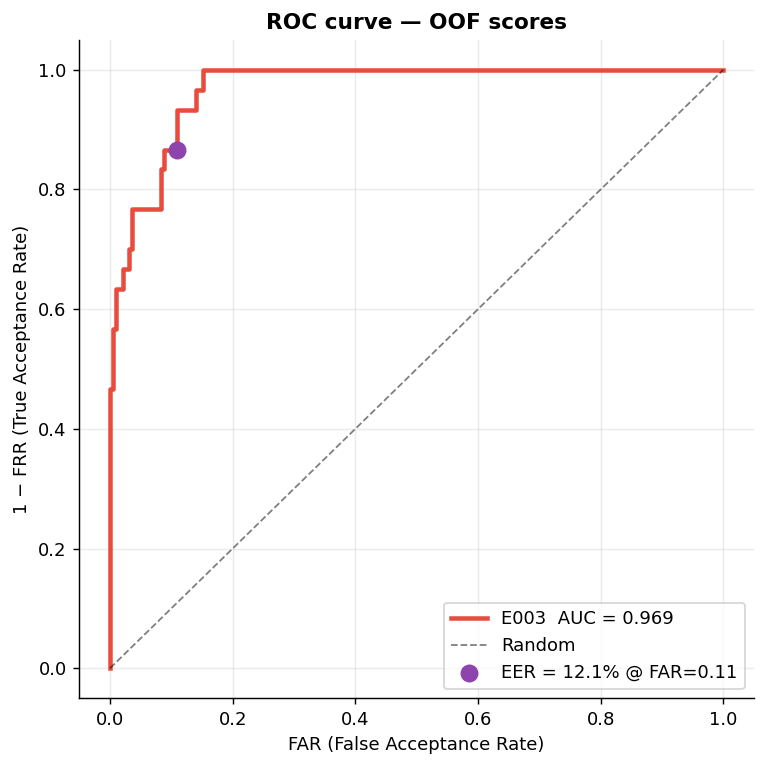

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

fpr, tpr, thresholds = roc_curve(y_all, oof_scores)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color=C_TARGET, lw=2.5, label=f"E003  AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")

# EER point
far_arr = fpr
frr_arr = 1 - tpr
idx_eer = np.argmin(np.abs(far_arr - frr_arr))
ax.scatter(far_arr[idx_eer], tpr[idx_eer],
           color=C_PURPLE, zorder=5, s=80,
           label=f"EER = {eer_oof*100:.1f}% @ FAR={far_arr[idx_eer]:.2f}")

ax.set_xlabel("FAR (False Acceptance Rate)")
ax.set_ylabel("1 − FRR (True Acceptance Rate)")
ax.set_title("ROC curve — OOF scores", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Visualisation 3 — DET curve

The DET (Detection Error Trade-off) curve plots FRR vs. FAR on a **probit
(inverse-normal) scale**.  This linearises Gaussian-like score distributions
and is the standard visualisation for speaker/face verification systems.  The
**EER diagonal** ($y = x$) crosses the DET curve exactly at the EER operating
point.

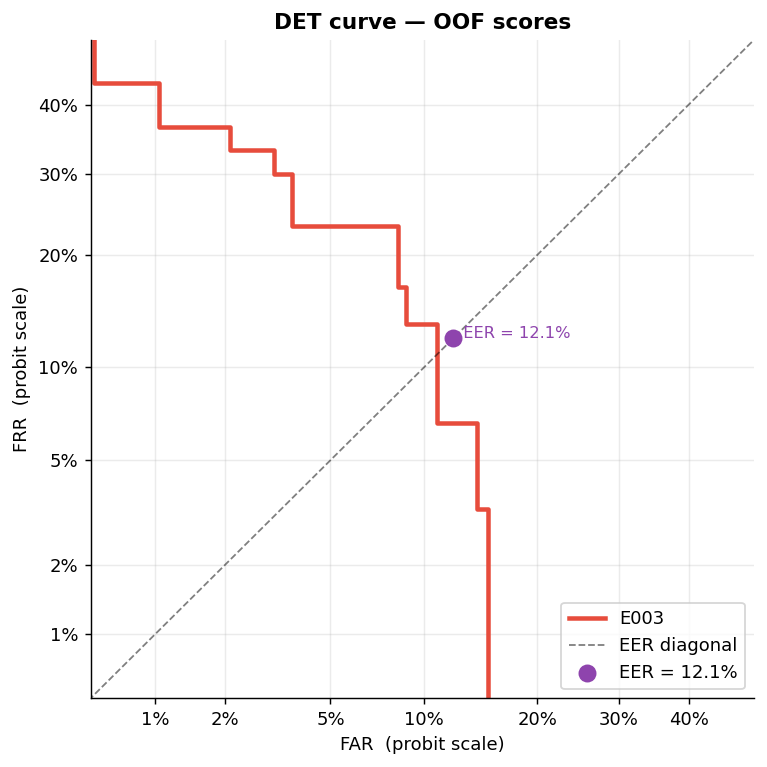

In [8]:
def probit(p, eps=1e-6):
    return sp_norm.ppf(np.clip(p, eps, 1 - eps))


fig, ax = plt.subplots(figsize=(6, 6))

far_arr = fpr
frr_arr = 1 - tpr

ax.plot(probit(far_arr), probit(frr_arr),
        color=C_TARGET, lw=2.5, label="E003")

# EER diagonal on probit scale
lim_vals = np.array([0.001, 0.5])
ax.plot(probit(lim_vals), probit(lim_vals),
        "k--", lw=1, alpha=0.5, label="EER diagonal")

# EER point
idx_eer = np.argmin(np.abs(far_arr - frr_arr))
eer_x   = (far_arr[idx_eer] + frr_arr[idx_eer]) / 2
ax.scatter(probit(eer_x), probit(eer_x),
           color=C_PURPLE, zorder=5, s=80, label=f"EER = {eer_x*100:.1f}%")
ax.annotate(f"  EER = {eer_x*100:.1f}%",
            xy=(probit(eer_x), probit(eer_x)),
            fontsize=9, color=C_PURPLE)

ticks_pct = [1, 2, 5, 10, 20, 30, 40]
tick_vals  = [t / 100 for t in ticks_pct]
ax.set_xticks(probit(tick_vals))
ax.set_xticklabels([f"{t}%" for t in ticks_pct])
ax.set_yticks(probit(tick_vals))
ax.set_yticklabels([f"{t}%" for t in ticks_pct])

ax.set_xlim(probit(0.005), probit(0.5))
ax.set_ylim(probit(0.005), probit(0.5))
ax.set_xlabel("FAR  (probit scale)")
ax.set_ylabel("FRR  (probit scale)")
ax.set_title("DET curve — OOF scores", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Visualisation 4 — Per-fold EER bar chart

Horizontal bars for each fold.  Bars greener than the mean line are better
than average; bars coloured red are worse.  The grey band shows ±1 std around
the mean.  High variance across folds signals that a model is inconsistent —
possibly over-fitting to the training sessions of the target speaker.

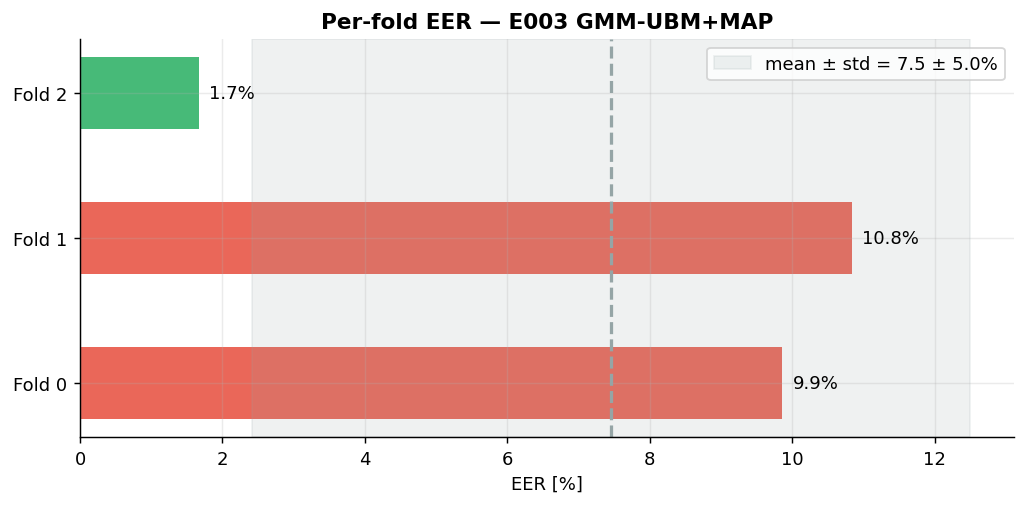

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

folds_eer = [r["eer"] * 100 for r in fold_results]
fold_labels = [f"Fold {r['fold']}" for r in fold_results]
colors = [C_GREEN if e <= mean_eer * 100 else C_TARGET for e in folds_eer]

bars = ax.barh(fold_labels, folds_eer, color=colors, alpha=0.85, height=0.5)

# Mean ± std band
ax.axvspan(mean_eer * 100 - std_eer * 100,
           mean_eer * 100 + std_eer * 100,
           alpha=0.15, color=C_GRAY, label=f"mean ± std = {mean_eer*100:.1f} ± {std_eer*100:.1f}%")
ax.axvline(mean_eer * 100, color=C_GRAY, lw=1.8, ls="--")

for bar, eer_val in zip(bars, folds_eer):
    ax.text(eer_val + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{eer_val:.1f}%", va="center", fontsize=10)

ax.set_xlabel("EER [%]")
ax.set_title("Per-fold EER — E003 GMM-UBM+MAP", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Visualisation 5 — MAP adaptation shift (PCA projection, fold 0)

MAP adaptation moves each GMM component mean slightly toward the target
speaker's acoustic subspace.  To see this geometrically, we project the 39-D
UBM means and the corresponding adapted means into 2-D via PCA.

- **Circles (steelblue):** UBM component means (the prior)
- **Triangles (tomato):** adapted means (posterior after seeing target frames)
- **Arrows:** the MAP shift vector $\Delta\mu_k = \mu_k' - \mu_k^{\text{UBM}}$

Arrow opacity encodes shift magnitude — darker arrows indicate components
strongly pulled by target data.  If only a few components shift noticeably,
it suggests the target speaker's voice occupies a compact acoustic region.

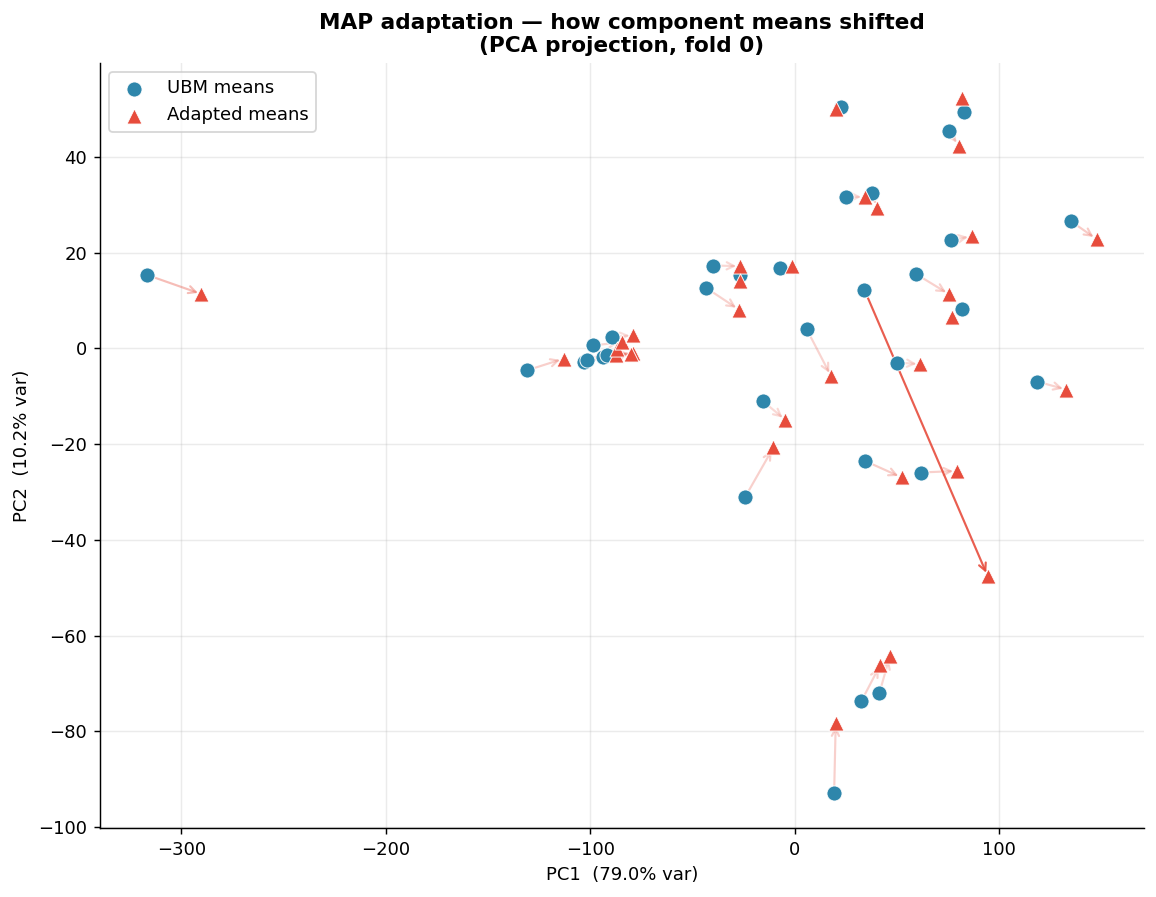

In [10]:
ubm0     = fold_models[0]["ubm"]
adapted0 = fold_models[0]["adapted"]

ubm_means     = ubm0.means_        # (K, D)
adapted_means = adapted0.means_    # (K, D)

# Fit PCA on combined means
pca   = PCA(n_components=2, random_state=SEED)
both  = np.vstack([ubm_means, adapted_means])
both2 = pca.fit_transform(both)
K     = len(ubm_means)
ubm2  = both2[:K]
ada2  = both2[K:]

# Shift magnitudes for alpha encoding
shifts   = np.linalg.norm(adapted_means - ubm_means, axis=1)
alphas   = (shifts - shifts.min()) / (shifts.max() - shifts.min() + 1e-10)
alphas   = 0.15 + 0.75 * alphas   # remap to [0.15, 0.90]

fig, ax = plt.subplots(figsize=(9, 7))

for k in range(K):
    dx = ada2[k, 0] - ubm2[k, 0]
    dy = ada2[k, 1] - ubm2[k, 1]
    ax.annotate("", xy=(ada2[k, 0], ada2[k, 1]),
                xytext=(ubm2[k, 0], ubm2[k, 1]),
                arrowprops=dict(arrowstyle="->", color=C_TARGET,
                                alpha=float(alphas[k]), lw=1.2))

ax.scatter(ubm2[:, 0], ubm2[:, 1],
           s=70, c=C_NONTARGET, marker="o", zorder=4,
           label="UBM means", edgecolors="white", linewidths=0.5)
ax.scatter(ada2[:, 0], ada2[:, 1],
           s=70, c=C_TARGET, marker="^", zorder=5,
           label="Adapted means", edgecolors="white", linewidths=0.5)

var_exp = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1  ({var_exp[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2  ({var_exp[1]*100:.1f}% var)")
ax.set_title(
    "MAP adaptation — how component means shifted\n"
    "(PCA projection, fold 0)",
    fontweight="bold"
)
ax.legend()
plt.tight_layout()
plt.show()

## Visualisation 6 — Adaptation magnitude histogram

For fold 0, we compute $\|\mu_k' - \mu_k^{\text{UBM}}\|_2$ for each of the
32 components.  The distribution tells us:

- **Right-heavy tail:** a few Gaussian components are strongly attracted by the
  target speaker, i.e., the target voice concentrates energy in a small
  acoustic region.
- **Roughly uniform:** the speaker's voice spreads across the full feature
  space, and all components adapt similarly.

Components with near-zero shift received almost no target frames in the
E-step, so the adaptation weight $\alpha_k \approx 0$ and they stay close
to the UBM prior.

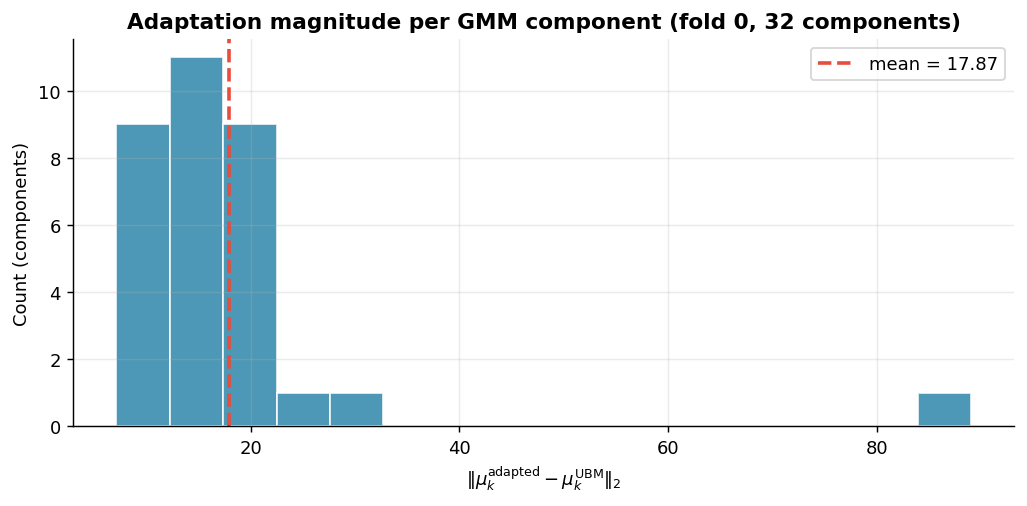

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(shifts, bins=16, color=C_NONTARGET, edgecolor="white", alpha=0.85)
ax.axvline(shifts.mean(), color=C_TARGET, lw=2, ls="--",
           label=f"mean = {shifts.mean():.2f}")

ax.set_xlabel(r"$\|\mu_k^{\rm adapted} - \mu_k^{\rm UBM}\|_2$")
ax.set_ylabel("Count (components)")
ax.set_title("Adaptation magnitude per GMM component (fold 0, 32 components)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Visualisation 7 — E001 → E002 → E003 progression

Side-by-side per-fold EER bars for all three experiments.  Each group of
three bars corresponds to one fold; the annotation above each group shows
the mean ± std for that experiment across folds.  This is the clearest
way to see whether the gains are consistent or fold-dependent:

- **E001 (gray):** static 13-D MFCC, independent GMM — the weakest baseline.
- **E002 (steelblue):** added Δ+ΔΔ to the feature vector — consistent
  improvement, especially on fold 2.
- **E003 (tomato):** UBM + MAP — we expect further improvement through
  better-regularised target modelling.

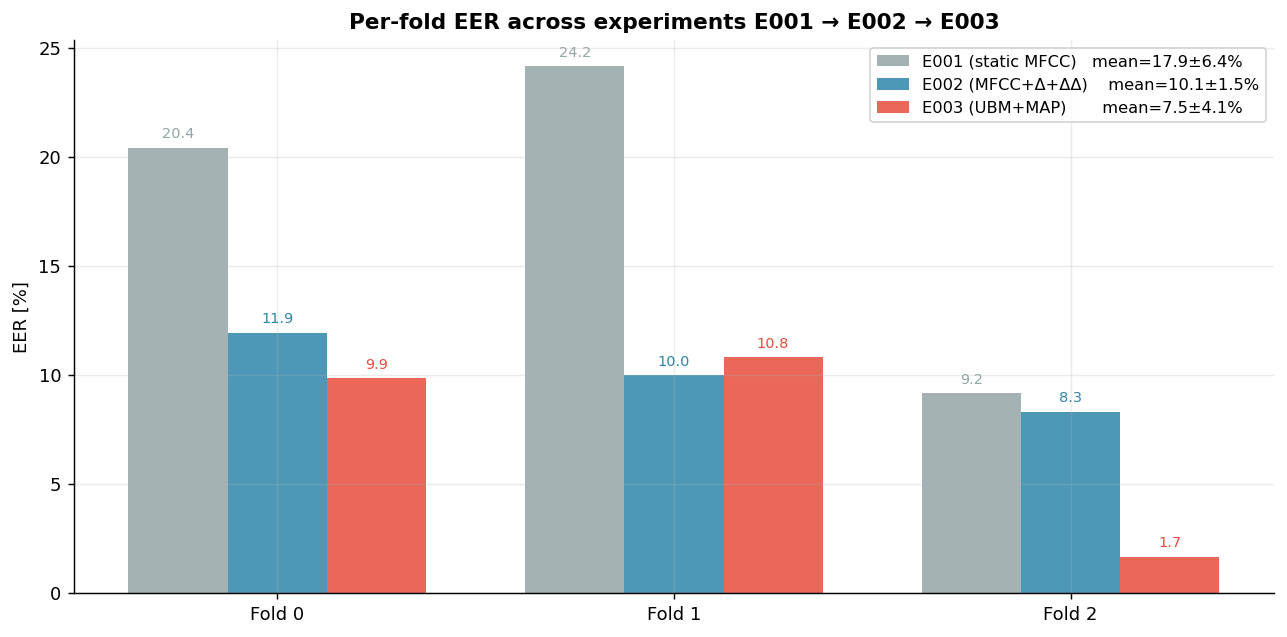

In [12]:
e001 = np.array([20.42, 24.17, 9.17])
e002 = np.array([11.94, 10.00, 8.33])
e003 = np.array([r["eer"] * 100 for r in fold_results])

e001_mean, e001_std = e001.mean(), e001.std()
e002_mean, e002_std = e002.mean(), e002.std()
e003_mean, e003_std = e003.mean(), e003.std()

n_folds   = len(e001)
x         = np.arange(n_folds)
bar_width  = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x - bar_width, e001, width=bar_width, color=C_GRAY,      alpha=0.85,
            label=f"E001 (static MFCC)   mean={e001_mean:.1f}±{e001_std:.1f}%")
b2 = ax.bar(x,             e002, width=bar_width, color=C_NONTARGET, alpha=0.85,
            label=f"E002 (MFCC+Δ+ΔΔ)    mean={e002_mean:.1f}±{e002_std:.1f}%")
b3 = ax.bar(x + bar_width, e003, width=bar_width, color=C_TARGET,    alpha=0.85,
            label=f"E003 (UBM+MAP)       mean={e003_mean:.1f}±{e003_std:.1f}%")

# Annotate mean±std above each group
y_max = max(e001.max(), e002.max(), e003.max())
annot_y = y_max + 1.5
for i, (exp, m, s, c) in enumerate([
    (e001, e001_mean, e001_std, C_GRAY),
    (e002, e002_mean, e002_std, C_NONTARGET),
    (e003, e003_mean, e003_std, C_TARGET),
]):
    xpos = x + (i - 1) * bar_width
    for j, (xp, v) in enumerate(zip(xpos, exp)):
        ax.text(xp, v + 0.3, f"{v:.1f}", ha="center", va="bottom",
                fontsize=8, color=c)

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(n_folds)])
ax.set_ylabel("EER [%]")
ax.set_title("Per-fold EER across experiments E001 → E002 → E003",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Interpretation and next steps

**What the visualisations tell us:**

1. **Score distributions (Viz 1):** Better-separated histograms than E002
   would confirm that MAP adaptation tightens the target model.  If fold 2
   still shows more overlap, it hints the third session is acoustically
   more variable.

2. **ROC / DET (Viz 2–3):** A DET curve that drops toward the bottom-left
   and an EER below ~8% would signal that UBM regularisation is working.

3. **Per-fold EER (Viz 4):** Low std across folds is the key indicator that
   the model generalises rather than memorising individual sessions.

4. **MAP shift (Viz 5–6):** If only ~5–10 components shift significantly,
   we may consider a *supervector* feature (concatenated adapted means) for
   a downstream classifier — this is the i-vector intuition.

**Possible next steps:**

- E004: Tune `n_components` (16, 64, 128) and relevance factor `r`.
- E005: Score normalisation (ZT-norm) — helps with threshold calibration.
- E006: Supervector SVM on the MAP-adapted means — a classical mid-2000s
  approach that outperforms raw GMM scoring on small corpora.
- Fusion: combine GMM-UBM LLR (audio) with image classifier scores.